In [17]:
# imports
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# plotting Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing, model selection
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# metrics
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [18]:
# random_state
SEED = 40

# Load train data
df_train = pd.read_csv('../data/train.csv')
df_train.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


Perhaps, we can drop Time feature since it have near zero MI score.

# Data Preprocessing 

### Builidng undersample

In [19]:
df_train = df_train.sample(frac=1, random_state=SEED) # shuffle dataframe
 # 1st takee all fraud cases
df_fraud = df_train.loc[df_train['IsFraud']==1]
#  2nd take random non fraud cases for the same rows number (they were shuffeled earlier)
df_nonfraud = df_train.loc[df_train['IsFraud']==0].sample(n=len(df_fraud), replace=False, random_state=SEED)
df_balanced_undersample = pd.concat([df_fraud, df_nonfraud]) # concatenate fraud and non fraud parts into one table
df_balanced_undersample = df_balanced_undersample.sample(frac=1, random_state=SEED) # shuffle them again

df_balanced_undersample.head(10)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
11647,11647,13193.0,0.953929,-0.853731,0.889266,-0.629727,-1.226058,-0.124916,-0.845368,0.159949,...,0.091416,0.446475,-0.136626,-0.037544,0.313968,-0.727070,0.050572,0.039373,118.63,1
108570,108570,62863.0,1.315404,-0.033577,-1.157476,-0.557087,2.029931,3.268130,-0.534994,0.808250,...,-0.313307,-1.068934,0.103797,0.992126,0.369398,0.110374,-0.028302,0.011836,5.99,0
5154,5154,1719.0,-3.926970,1.591747,-3.651351,5.717551,3.759827,-2.266875,0.726805,-2.907956,...,2.203823,-0.938597,-1.534221,-0.433038,-0.324845,0.409565,1.251167,-0.926380,0.77,1
53771,53771,47716.0,1.122965,-0.399604,1.089910,0.844644,-0.797722,0.816451,-0.832638,0.403618,...,-0.128957,0.039232,-0.079172,-0.211858,0.445906,0.496436,0.068363,0.005430,4.00,1
91669,91669,58486.0,-0.547002,1.536908,-0.008971,1.099760,1.163819,-0.764134,1.079651,-0.291460,...,0.031196,0.084533,-0.059995,-0.191469,-0.392627,-0.282715,0.065284,0.271826,1.00,1
145616,145616,72980.0,-7.154899,-3.503533,-0.388839,1.845896,1.847447,0.865603,-0.332529,0.459859,...,-1.089856,1.155513,4.347078,-1.084889,0.737983,-0.170080,-0.672669,2.251628,22.00,0
15896,15896,23444.0,-2.843267,3.262912,-3.634127,2.129876,-0.242560,-1.636653,-0.331530,1.973124,...,-0.441349,-1.154959,0.154487,-0.373627,0.069049,-0.704716,-0.007516,-0.068953,89.99,1
7305,7305,5248.0,-1.022959,1.409612,1.503601,0.241218,0.140544,-0.592368,0.624656,-0.826351,...,-0.142736,0.333733,-0.235737,0.360816,0.020860,-0.585824,-0.481738,-0.273936,6.99,0
125393,125393,67702.0,1.130293,-0.090812,1.216001,1.136534,-0.805966,0.275249,-0.709291,0.293914,...,-0.015351,0.056191,-0.004653,-0.005606,0.345278,-0.402289,0.065204,0.026502,4.99,1
140070,140070,71747.0,0.408622,1.011738,0.183321,1.894079,0.331236,-0.667899,0.942603,-0.461909,...,0.223341,0.944361,0.008385,0.580149,-1.119291,-0.260375,0.001614,0.033947,18.28,1


We have balanced undersample now

C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\106595873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_train, palette=colors)
C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\106595873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)


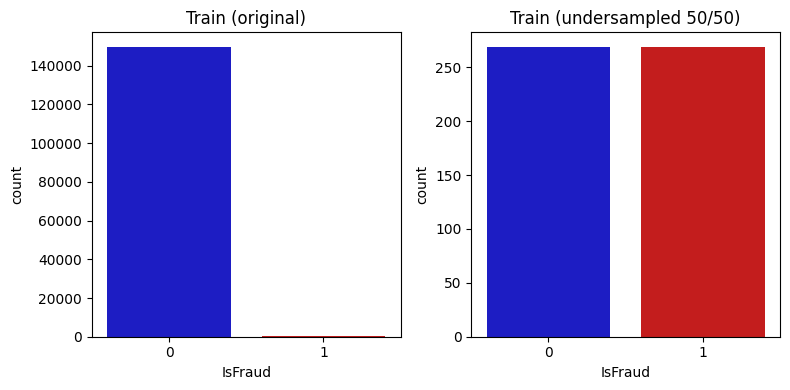

In [20]:
colors = ["#0101DF", "#DF0101"] # Fraud / non Fraud count plot colors

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='IsFraud', data=df_train, palette=colors)
plt.title('Train (original)')

plt.subplot(1,2,2)
sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)
plt.title('Train (undersampled 50/50)')

plt.tight_layout()

Now lets take a look at a correlation matrixes for the undersample and the full dataframe

### Feature Scaling

We saw in 01_eda.ipynb that all features are scaled except for the 'Time' and the 'Transaction_Amount'.
To keep same magnitute for modeling we will perform scalers for both features.
We will use RobustScaler for the 'Transaction_Amount' column as it have outliers and StandardScaler for the 'Time' column.

In [21]:
# Scaling Time and amount values.
rob_scaler = RobustScaler() # is less prone to outliers
stnd_scaler = StandardScaler()

# df_train['scaled_Transaction_Amount'] = rob_scaler.fit_transform(df_train['Transaction_Amount'].values.reshape(-1,1))
# df_train['scaled_time'] = stnd_scaler.fit_transform(df_train['Time'].values.reshape(-1,1))

# df_train.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

# # we have done it, but now we need to place columns at the first and second placee in our dataframe

# scaled_amount = df_train['scaled_Transaction_Amount']
# scaled_time = df_train['scaled_time']

# df_train.drop(['scaled_Transaction_Amount', 'scaled_time'], axis=1, inplace=True)
# df_train.insert(0, 'scaled_Transaction_Amount', scaled_amount)
# df_train.insert(1, 'scaled_time', scaled_time)

In [22]:
column_scale = ColumnTransformer(
    transformers= [
        ('robust_scaler', rob_scaler, ['Transaction_Amount']),
        ('stnd_scaler', stnd_scaler, ['Time'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)

# pipeline = Pipeline(steps=[
#     ('preprocessor', column_scale),
#     ('model', model)
# ]
# )

In [23]:
df_train_p = column_scale.fit_transform(df_train)
# return dataframe with original column names
col = column_scale.get_feature_names_out()
df_train_scaled = pd.DataFrame(df_train_p, columns = col, index = df_train.index)
df_train_scaled.head(5)

,Transaction_Amount,Time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
135088,0.523802,1.121012,135088.0,-0.757947,-0.392878,2.035651,-2.371615,-1.154433,-0.410098,-0.078361,...,-0.262337,-0.215775,-0.049643,-0.142566,0.033209,0.347895,-0.443559,0.049680,0.082913,0.0
49945,3.215938,-0.184931,49945.0,0.653930,-0.812996,0.466067,1.519816,-0.505959,0.923742,-0.149916,...,0.267906,0.107392,0.097918,-0.339534,-0.244037,0.569257,-0.251625,0.018239,0.043000,0.0
22644,0.040143,-0.887573,22644.0,-0.529005,0.464891,1.953446,1.132813,0.332364,0.596740,0.414819,...,0.078587,0.052718,0.666767,-0.255500,0.194851,0.267723,-0.216928,-0.035005,-0.149917,0.0
14600,-0.194747,-1.553542,14600.0,-0.838504,0.456030,2.721679,-1.942708,-0.316868,-0.311899,0.439705,...,-0.010924,-0.166086,0.208252,-0.344080,0.173927,0.371368,-0.795417,-0.368812,-0.300919,0.0
10753,-0.342039,-2.066898,10753.0,-1.953688,2.531524,0.829018,0.472421,-0.951760,0.953875,-4.262436,...,2.569677,-6.164514,0.569140,1.092969,0.574815,-0.175721,-0.055909,0.050198,0.239833,0.0


In [24]:
df_balanced_undersample_scaled = column_scale.fit_transform(df_balanced_undersample)

col = column_scale.get_feature_names_out()
df_balanced_undersample_scaled = pd.DataFrame(df_balanced_undersample_scaled, columns = col, index = df_balanced_undersample.index)
df_balanced_undersample_scaled.head(5)

,Transaction_Amount,Time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
11647,1.606169,-1.838387,11647.0,0.953929,-0.853731,0.889266,-0.629727,-1.226058,-0.124916,-0.845368,...,-0.011131,0.091416,0.446475,-0.136626,-0.037544,0.313968,-0.727070,0.050572,0.039373,1.0
108570,-0.139647,0.712615,108570.0,1.315404,-0.033577,-1.157476,-0.557087,2.029931,3.268130,-0.534994,...,0.016952,-0.313307,-1.068934,0.103797,0.992126,0.369398,0.110374,-0.028302,0.011836,0.0
5154,-0.220552,-2.427680,5154.0,-3.926970,1.591747,-3.651351,5.717551,3.759827,-2.266875,0.726805,...,-0.738004,2.203823,-0.938597,-1.534221,-0.433038,-0.324845,0.409565,1.251167,-0.926380,1.0
53771,-0.170490,-0.065320,53771.0,1.122965,-0.399604,1.089910,0.844644,-0.797722,0.816451,-0.832638,...,-0.111502,-0.128957,0.039232,-0.079172,-0.211858,0.445906,0.496436,0.068363,0.005430,1.0
91669,-0.216987,0.487816,91669.0,-0.547002,1.536908,-0.008971,1.099760,1.163819,-0.764134,1.079651,...,0.141547,0.031196,0.084533,-0.059995,-0.191469,-0.392627,-0.282715,0.065284,0.271826,1.0


All the features are scaled now.

need to scale before plot corr plots

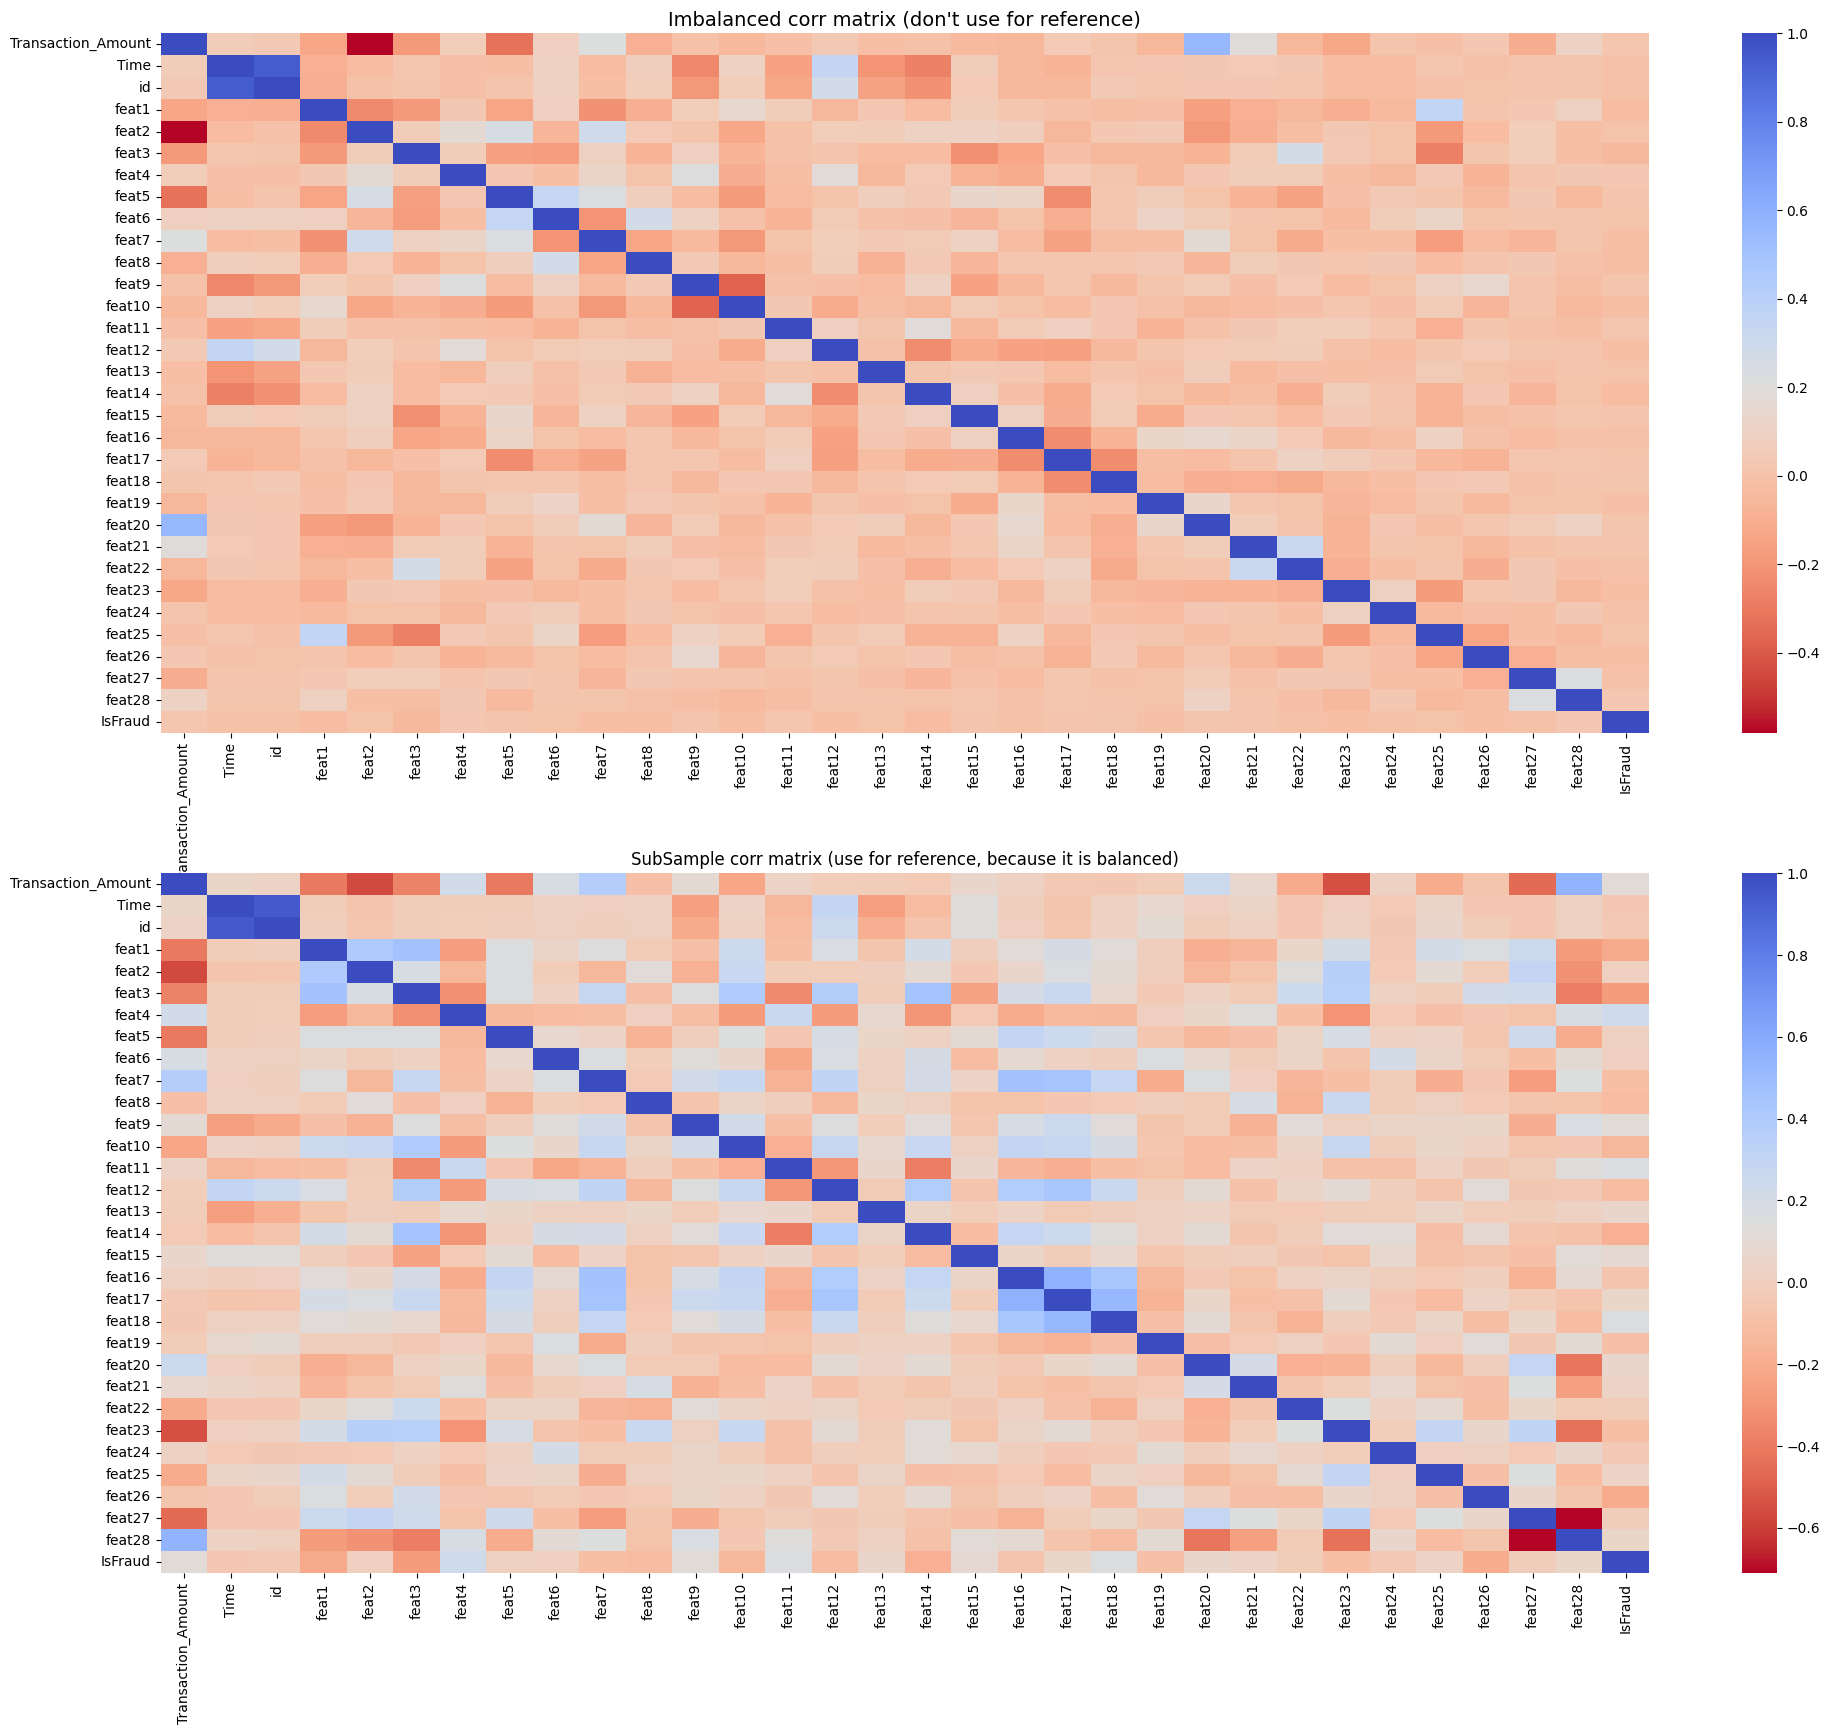

In [25]:
# now lets look at corr matrix for the new and old df (full)
f, (ax1, ax2) = plt.subplots(2,1,figsize=(24,20))

corr = df_train_scaled.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced corr matrix (don't use for reference)", fontsize=14)

sub_sample_corr = df_balanced_undersample_scaled.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title("SubSample corr matrix (use for reference, because it is balanced)")
plt.show()

Corr matrix of undersample shown correlations for isFraud in comparison with unbalanced train dataframe. However, we see only few features which negatively correlates with isFraud column: feat1, feat3, feat26


C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\3225684181.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\3225684181.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\3225684181.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat26', data

Text(0.5, 1.0, 'feat19 vs class negative corr')

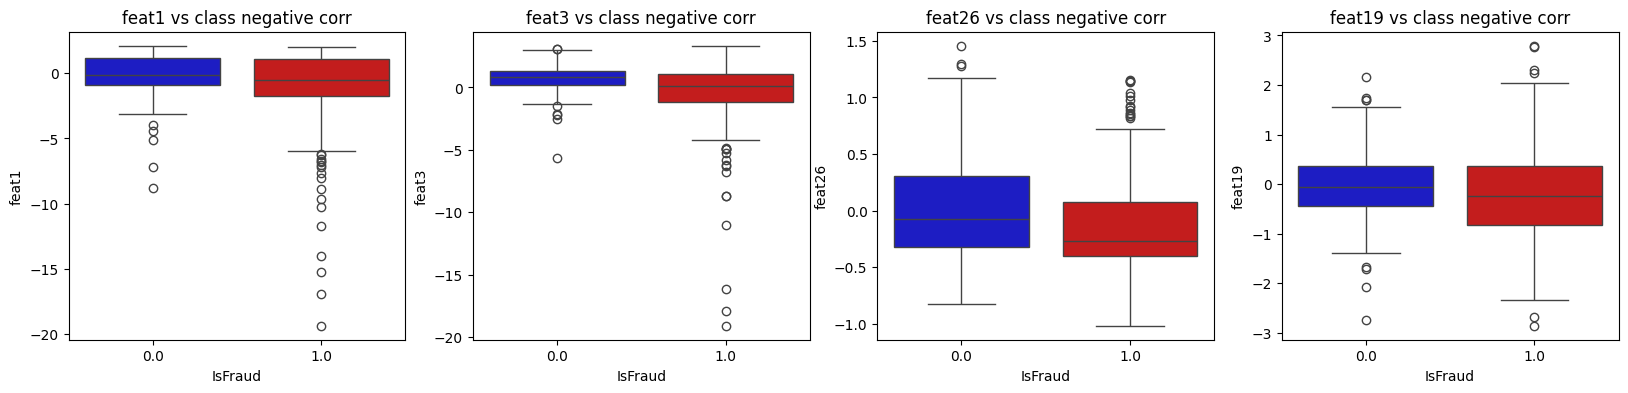

In [26]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
axes[0].set_title('feat1 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
axes[1].set_title('feat3 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_undersample_scaled, palette=colors, ax=axes[2])
axes[2].set_title('feat26 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat19', data=df_balanced_undersample_scaled, palette=colors, ax=axes[3])
axes[3].set_title('feat19 vs class negative corr')




We see only few features which positive correlates with isFraud column: feat4 , feat11, feat18, feat15


C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\2408817435.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\2408817435.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_13680\2408817435.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat18', dat

Text(0.5, 1.0, 'feat15 vs class positive corr')

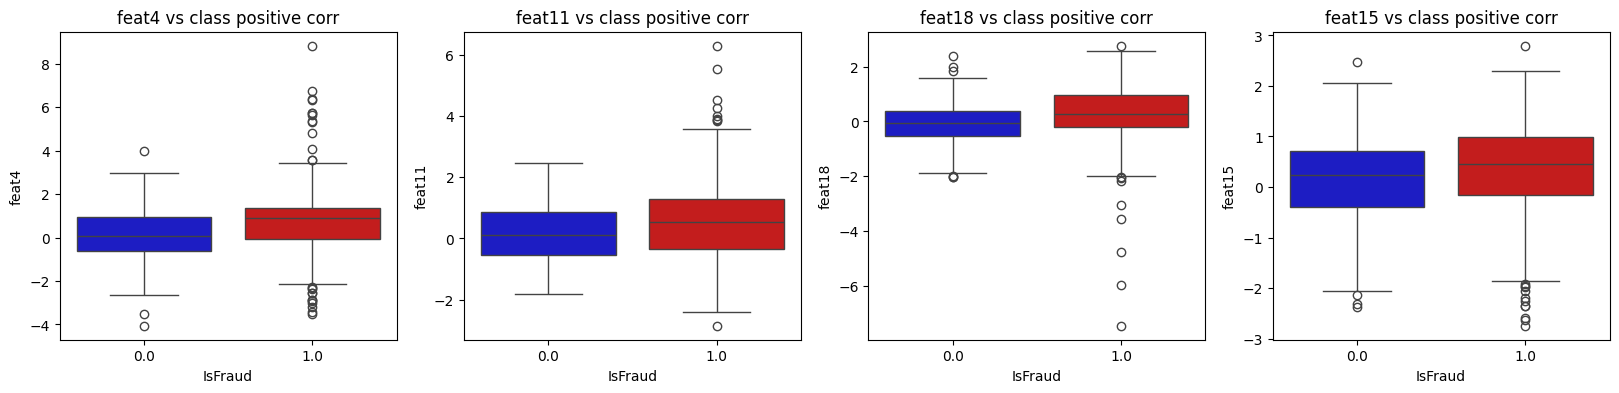

In [27]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
axes[0].set_title('feat4 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
axes[1].set_title('feat11 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_undersample_scaled, palette=colors, ax=axes[2])
axes[2].set_title('feat18 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat15', data=df_balanced_undersample_scaled, palette=colors, ax=axes[3])
axes[3].set_title('feat15 vs class positive corr')

We see a small differences in the correllated features, nothing outstanding. Lets take a look at a feature importance from Mutual Information perspective.

In [28]:
# Split X and y
# df_balanced_undersample = df_balanced_undersample.copy()
y_balanced_undersample = df_balanced_undersample_scaled['IsFraud']
X_balanced_undersample = df_balanced_undersample_scaled.drop(columns=['IsFraud','id'])

Lets take a look at a feature importance from Mutual Information perspective.

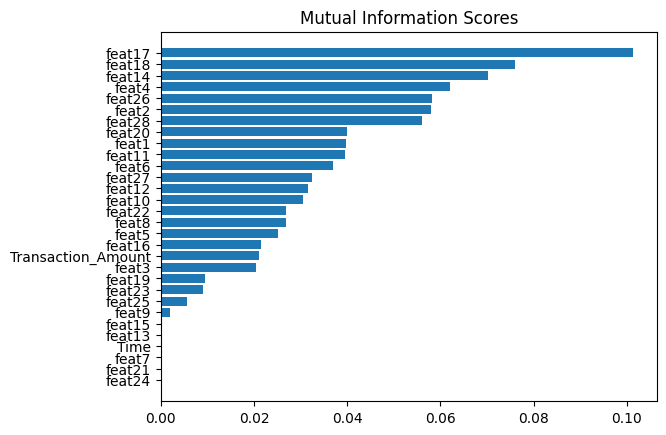

In [29]:
def make_mi_scores(X,y):
    X = X.copy()
    for colname in X.select_dtypes(['object', 'category']):
        x[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X,y, discrete_features = discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    '''Input: pandas series from def make_mi_scores'''
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')

mi_scores = make_mi_scores(X_balanced_undersample,y_balanced_undersample)
plot_mi_scores(mi_scores)

That could help us to drop features with low MI score if we will need it in future, for instance for performance improvements. But now we just use all of them.

# Model comparison

Here we will test and choose the best classifier for balanced undersample. To avoid a data leakage we need to implement scaling after train-validation (test) split. Thus we do it again now.

In [35]:
X_train, X_valid, y_train, y_valid = train_test_split(X_balanced_undersample, y_balanced_undersample, test_size = 0.2, random_state=SEED)

In [ ]:
# Scaling features
X_train_scaled = column_scale.fit_transform(X_train) # output ndarray
X_valid_scaled = column_scale.fit_transform(X_valid) # output ndarray

# Values into arrays for feeding the classification algorithms
y_train = y_train.values
y_valid = y_valid.values

In [40]:
# Implement simple classifiers
classifiers = {
    "LogisticRegression" : LogisticRegression(random_state=SEED),
    "KNearest" : KNeighborsClassifier(),
    "Support Vector Classifier" : SVC(random_state=SEED),
    "DecisionTreeClassifier" : DecisionTreeClassifier(random_state=SEED),
    "Random Forest" : RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators = 400, max_depth = 3, learning_rate = 0.01, random_state=SEED
    ),
    "Neural Network" : MLPClassifier(
                                hidden_layer_sizes=(50,50),
                                activation='relu',
                                solver='adam',
                                alpha=1e-3,
                                learning_rate_init=1e-3,
                                early_stopping=True,
                                validation_fraction=0.1,
                                max_iter=500,
                                random_state=SEED
                            )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # shuffled 5 folds for cross_val_score

for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_valid)
    training_score = cross_val_score(classifier, X_train, y_train, cv=skf)
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "% accuracy score")
print("-------------------------")
for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_valid)
    training_score = cross_val_score(classifier, X_train, y_train, cv=skf, scoring='average_precision')
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "average_precision")

Classifiers: LogisticRegression Has a training score of 68.0 % accuracy score
Classifiers: KNeighborsClassifier Has a training score of 67.0 % accuracy score
Classifiers: SVC Has a training score of 70.0 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of 61.0 % accuracy score
Classifiers: RandomForestClassifier Has a training score of 66.0 % accuracy score
Classifiers: GradientBoostingClassifier Has a training score of 64.0 % accuracy score
Classifiers: MLPClassifier Has a training score of 64.0 % accuracy score
-------------------------
Classifiers: LogisticRegression Has a training score of 78.0 average_precision
Classifiers: KNeighborsClassifier Has a training score of 74.0 average_precision
Classifiers: SVC Has a training score of 81.0 average_precision
Classifiers: DecisionTreeClassifier Has a training score of 57.99999999999999 average_precision
Classifiers: RandomForestClassifier Has a training score of 80.0 average_precision
Classifiers: GradientBoosti

We choose the RandomForestClassifier since high level average_precision, accuracy, simplicity and performance. SVC also looks interesting.

In [41]:
# fit model
model = RandomForestClassifier(n_estimators=400, random_state=SEED)
model.fit(X_train,y_train)

# predictions for validation set
preds = model.predict(X_valid)

In [42]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_valid, preds))

              precision    recall  f1-score   support

         0.0       0.66      0.75      0.70        57
         1.0       0.67      0.57      0.62        51

    accuracy                           0.67       108
   macro avg       0.67      0.66      0.66       108
weighted avg       0.67      0.67      0.66       108



In [43]:
# 2) ROC AUC for overall separability
probs = model.predict_proba(X_valid)[:,1]
print('ROC AUC:', roc_auc_score(y_valid, probs))

ROC AUC: 0.7227382180942553


In [44]:
# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_valid, probs)
print('PR AUC', auc(recall, precision))

PR AUC 0.7270070673420408


<function matplotlib.pyplot.show(close=None, block=None)>

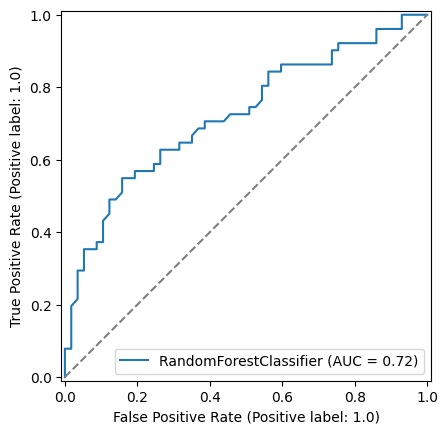

In [45]:
disp = RocCurveDisplay.from_estimator(
    model, X_valid, y_valid,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

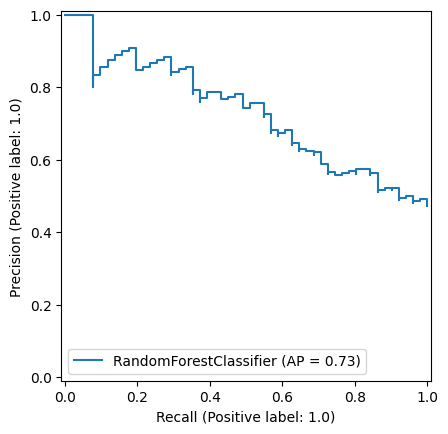

In [46]:
disp2 = PrecisionRecallDisplay.from_estimator(
    model, X_valid, y_valid,
)
plt.show()

# Submission

In [47]:
test_df = pd.read_csv('../data/test.csv')
test_ids = test_df['id'].copy()

submission_data = test_df.drop('id', axis=1)

In [48]:
# Scaling Time and amount values.

submission_data['scaled_Transaction_Amount'] = rob_scaler.transform(submission_data['Transaction_Amount'].values.reshape(-1,1))
submission_data['scaled_time'] = stnd_scaler.transform(submission_data['Time'].values.reshape(-1,1))

submission_data.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

NotFittedError: This RobustScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
preds_for_submission = model.predict_proba(submission_data)

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
output = pd.DataFrame(
    {
        'id' : test_ids.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output

,id,IsFraud
0,150000,0.4600
1,150001,0.3450
2,150002,0.6100
3,150003,0.3625
4,150004,0.4700
...,...,...
69124,219124,0.6000
69125,219125,0.6825
69126,219126,0.6425
69127,219127,0.6100


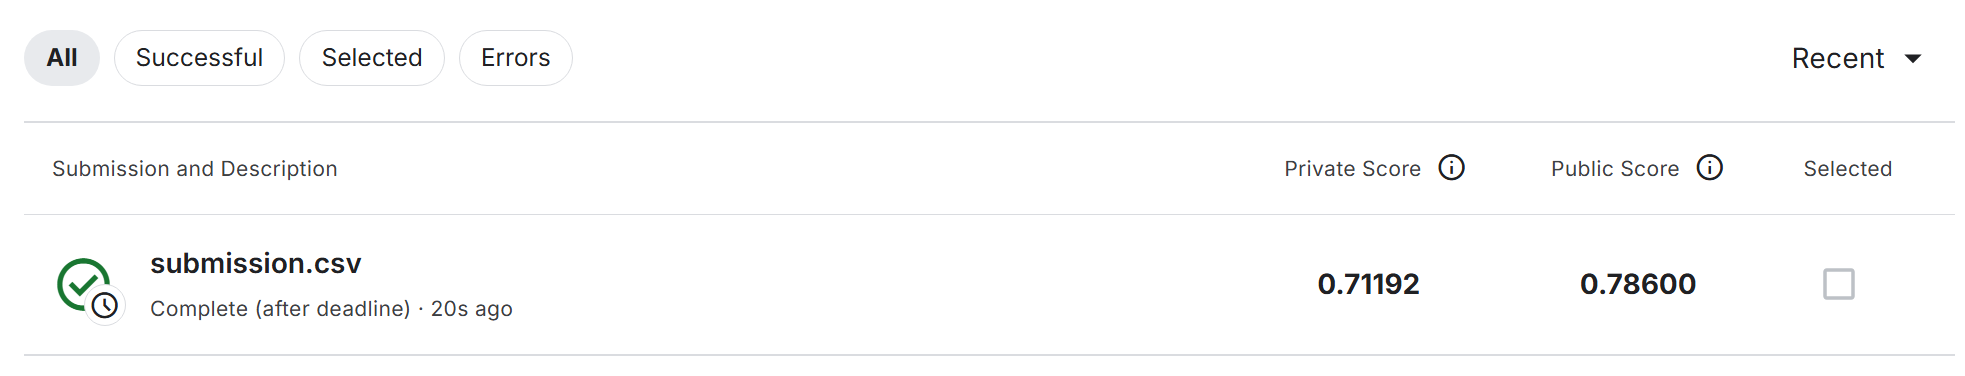

private score 71.1192 public score 0.78600